# Assorbimento di luce in funzione dello spessore

A cura di Giovanni N. D'Aloisio, matricola 494722, A.A. 2022-23.

##Introduzione

La propagazione di un'onda elettromagnetica in un mezzo è ben descritta dalla legge:

$$I(z,t)=I_0 \ \Big| \ e^{-i ( \omega t - \frac{2 \pi}{\lambda} nz)} \ \Big|^2 = I_0 \ e^{- \frac{4 \pi}{\lambda} Im(n) z} = I_0 \ e^{- \alpha z}$$

con $\alpha$ coefficiente di assorbimento del mezzo, e $I$ è l'intensità dell'onda misurata, in questo caso rivelata con un segnale di tensione. Questa è spesso indicata come *legge di Lambert-Beer*, conosciuta anche come *legge di Beer-Lambert* o *di Beer-Lambert-Bouguer*.

Considerando un raggio luminoso che si propaga in aria ($n=1$, $\alpha=0$), quando questo incontra un mezzo avente $n=1.5$, $\alpha \neq 0$, attraversandolo per uno spessore $d$, viene parzialmente assorbito, riemergendo dalla faccia opposta con un'intensità (misurabile) che, tenendo conto della riflessione alle interfacce, vale:

$$I_0 = (1 − R)^2 \ e^{− \alpha d}$$

Per valutare gli effetti di assorbimento, occorre avere misurato l’intensità incidente $I_0$; di conseguenza, si definisce la trasmittanza come $T=I/{I_0}$, che rappresenta la percentuale di radiazione che non viene assorbita dal materiale.

##Scopo dell'esperienza

Il principale obiettivo di questo esperimento è quello di verificare la legge di Lambert-Beer.

## Strumentazione

+ 1 LED (giallo o rosso);
+ 1 fotodiodo;
+ 1 schema di detezione, che garantisca risposta lineare dal fotodiodo;
+ 1 generatore di funzioni in grado di alimentare il LED in onda quadra (per renderne riconoscibile il segnale rispetto alla luce ambiente);
+ 1 oscilloscopio per visualizzare e misurare il segnale;
+ 2 lastrine in plexiglas;
+ 1 molletta;
+ una serie di foglietti plastici semitrasparenti colorati.

Un possibile schema dell'esperimento è il seguente:

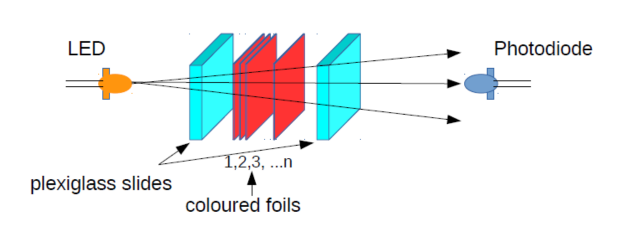

## Procedura sperimentale

Montato l'apparato sperimentale come mostrato nella figura precedente, si annota la trasmittanza T attraverso un numero crescente di foglietti, usando la molletta per ridurre al minimo la formazione di bolle tra di essi, comprimendoli tra le placche di plexiglas.

I dati così ottenuti vengono dunque normalizzati, mediante una misura con solo placche di plexiglas.

Una volta raccolti tutti questi dati, si può verificare l'andamento esponenziale in funzione del numero di foglietti, riportando anche la grandezza $A = - \ln T$ in funzione di tale numero.

## Importazione e analisi dei dati sperimentali

Di seguito sono riportati gli snippets utilizzati per l'analisi dei dati, in questo caso con un LED blu. Chiaramente, è possibile sostituire il file di input con quello verde, giallo o rosso, per visualizzare come varia la risposta della legge di Lambert-Beer; tuttavia si giungerà alle stesse conclusioni in ognuno dei quattro casi.

Su [GitHub](https://github.com/nikitodos/UniPV_Physics_Lab_3/tree/main/06_LED_ABSORB) è possibile visualizzare i dati raccolti in formato tabulato.

In [ ]:
# Importa librerie di lavoro

import numpy as np
from scipy import optimize as sop
from scipy import constants as scc
import matplotlib.pyplot as plt  
import pandas as pd

### LED blu 

In [ ]:
# Definisci funzione di fit

def function_blue(N,alpha,Ib):
    I = I0_blue*np.exp(-alpha*N)+Ib
    return I

def function_red(N,alpha,Ib):
    I = I0_red*np.exp(-alpha*N)+Ib
    return I

def function_yellow(N,alpha,Ib):
    I = I0_yellow*np.exp(-alpha*N)+Ib
    return I

# Importa i dati

blue = 'https://github.com/nikitodos/UniPV_Physics_Lab_3/raw/main/06_LED_ABSORB/LED_BLUE/LAYERS_BLUE.CSV'
red = 'https://github.com/nikitodos/UniPV_Physics_Lab_3/raw/main/06_LED_ABSORB/LED_BLUE/LAYERS_RED.CSV'
yellow = 'https://github.com/nikitodos/UniPV_Physics_Lab_3/raw/main/06_LED_ABSORB/LED_BLUE/LAYERS_YELLOW.CSV'

blue = pd.read_csv(blue)
red = pd.read_csv(red)
yellow = pd.read_csv(yellow)

# Converti i dati in numpy arrays, usando unità del S.I.

sheet_number_blue=blue['Numero foglietti'].to_numpy()
intensity_blue=blue['Intensità segnale di uscita (mV)'].to_numpy()

sheet_number_red=red['Numero foglietti'].to_numpy()
intensity_red=red['Intensità segnale di uscita (mV)'].to_numpy()

sheet_number_yellow=yellow['Numero foglietti'].to_numpy()
intensity_yellow=yellow['Intensità segnale di uscita (mV)'].to_numpy()

# Definisci variabili di lavoro

I0_blue=intensity_blue[0]
ndata_blue=len(sheet_number_blue)
ni=len(intensity_blue)

I0_red=intensity_red[0]
ndata_red=len(sheet_number_red)
ni_red=len(intensity_red)

I0_yellow=intensity_yellow[0]
ndata_yellow=len(sheet_number_yellow)
ni_yellow=len(intensity_yellow)

print('Inizializzazione dei dati completata.')

Inizializzazione dei dati completata.


 
Dati del fit relativi al LED blu
 
Foglietti blu
Valore di fit del coefficiente di assorbimento:   alpha_fit = ( 1.3e-01  ± 3.2e-02  ) m^{-1}
Valore di fit dell'intensità di fondo:            Ib_fit    = ( 1.18e+01 ± 4.0e+01  ) V
 
Foglietti rossi
Valore di fit del coefficiente di assorbimento:   alpha_fit = ( 2.75e-01  ± 1.4e-01 ) m^{-1}
Valore di fit dell'intensità di fondo:            Ib_fit    = ( -1.12e+00 ± 3.8e+00 ) A
 
Foglietti gialli
Valore di fit del coefficiente di assorbimento:   alpha_fit = ( 3.29e-01  ± 1.3e-01 ) m^{-1}
Valore di fit dell'intensità di fondo:            Ib_fit    = ( -7.39e-02 ± 3.0e+00 ) A
 


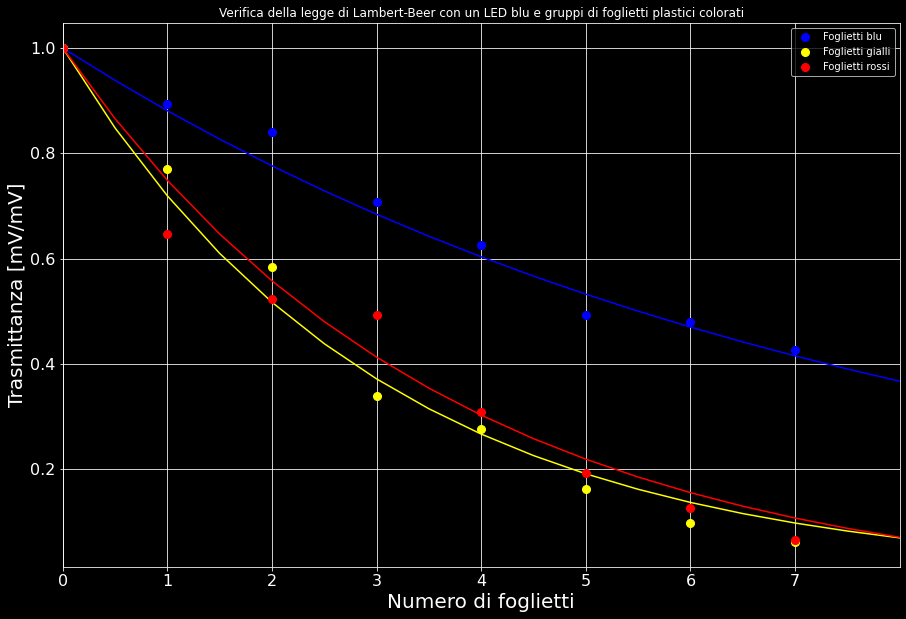

In [ ]:
# Fit dei dati

alpha_min, alpha_max = 0., 5
Ib_min, Ib_max = -100, 100
bounds = [ [alpha_min, Ib_min], [alpha_max, Ib_max] ]

popt, pcov=sop.curve_fit(function_blue, sheet_number_blue, intensity_blue, bounds=bounds)
alpha_fit_blue = popt[0]
Ib_fit_blue    = popt[1]
standard_error_blue = np.sqrt(np.diag(pcov))
sigma_blue = np.sqrt(ndata_blue*np.diag(pcov))

alpha_min, alpha_max = -100, 100
Ib_min, Ib_max = -1e5, 1e5
bounds = [ [alpha_min, Ib_min], [alpha_max, Ib_max] ]

popt, pcov=sop.curve_fit(function_red, sheet_number_red, intensity_red, bounds=bounds)
alpha_fit_red = popt[0]
Ib_fit_red    = popt[1]
standard_error_red = np.sqrt(np.diag(pcov))
sigma_red = np.sqrt(ndata_red*np.diag(pcov))

alpha_min, alpha_max = -100, 100
Ib_min, Ib_max = -1e5, 1e5
bounds = [ [alpha_min, Ib_min], [alpha_max, Ib_max] ]

popt, pcov=sop.curve_fit(function_yellow, sheet_number_yellow, intensity_yellow, bounds=bounds)
alpha_fit_yellow = popt[0]
Ib_fit_yellow    = popt[1]
standard_error_yellow = np.sqrt(np.diag(pcov))
sigma_yellow = np.sqrt(ndata_yellow*np.diag(pcov))

print(' ')

print('Dati del fit relativi al LED blu')

print(' ')

print('Foglietti blu')
print('Valore di fit del coefficiente di assorbimento:   alpha_fit = (',np.format_float_scientific(alpha_fit_blue,precision=2), ' ±', np.format_float_scientific(sigma_blue[0], precision=1), " ) m^{-1}")
print('Valore di fit dell\'intensità di fondo:            Ib_fit    = (',np.format_float_scientific(Ib_fit_blue,precision=2),   '±', np.format_float_scientific(sigma_blue[1], precision=1), " ) V")

print(' ')

print('Foglietti rossi') 
print('Valore di fit del coefficiente di assorbimento:   alpha_fit = (',np.format_float_scientific(alpha_fit_red,precision=2), ' ±', np.format_float_scientific(sigma_red[0], precision=1), ") m^{-1}")
print('Valore di fit dell\'intensità di fondo:            Ib_fit    = (',np.format_float_scientific(Ib_fit_red,precision=2),   '±', np.format_float_scientific(sigma_red[1], precision=1), ") A")

print(' ')

print('Foglietti gialli')
print('Valore di fit del coefficiente di assorbimento:   alpha_fit = (',np.format_float_scientific(alpha_fit_yellow,precision=2), ' ±', np.format_float_scientific(sigma_yellow[0], precision=1), ") m^{-1}")
print('Valore di fit dell\'intensità di fondo:            Ib_fit    = (',np.format_float_scientific(Ib_fit_yellow,precision=2),   '±', np.format_float_scientific(sigma_yellow[1], precision=1), ") A")

print(' ')

# Plot dati fittati più dati reali

plt.figure(figsize=[15,10])
xmin,xmax=0.,8.
x=np.arange(xmin,xmax+1e-5,0.5)
x_ticks=sheet_number_blue
plt.title('Verifica della legge di Lambert-Beer con un LED blu e gruppi di foglietti plastici colorati')
plt.xlim(xmin,xmax)
plt.xlabel('Numero di foglietti', fontsize=20)
plt.ylabel('Trasmittanza [mV/mV]', fontsize=20)
plt.xticks(ticks=x_ticks, fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)

plt.plot(sheet_number_blue, intensity_blue/max(intensity_blue), 'o',markersize=8,color='blue',label='Foglietti blu')
y_blue=function_blue(x,alpha_fit_blue,Ib_fit_blue)
plt.plot(x,y_blue/max(y_blue),color='blue')

plt.plot(sheet_number_yellow, intensity_yellow/max(intensity_yellow), 'o',markersize=8,color='yellow',label='Foglietti gialli')
y_yellow=function_yellow(x,alpha_fit_yellow,Ib_fit_yellow)
plt.plot(x,y_yellow/max(y_yellow),color='yellow')

plt.plot(sheet_number_red, intensity_red/max(intensity_red), 'o',markersize=8,color='red',label='Foglietti rossi')
y_red=function_red(x,alpha_fit_red,Ib_fit_red)
plt.plot(x,y_red/max(y_red),color='red')

plt.legend()
plt.style.use("dark_background")


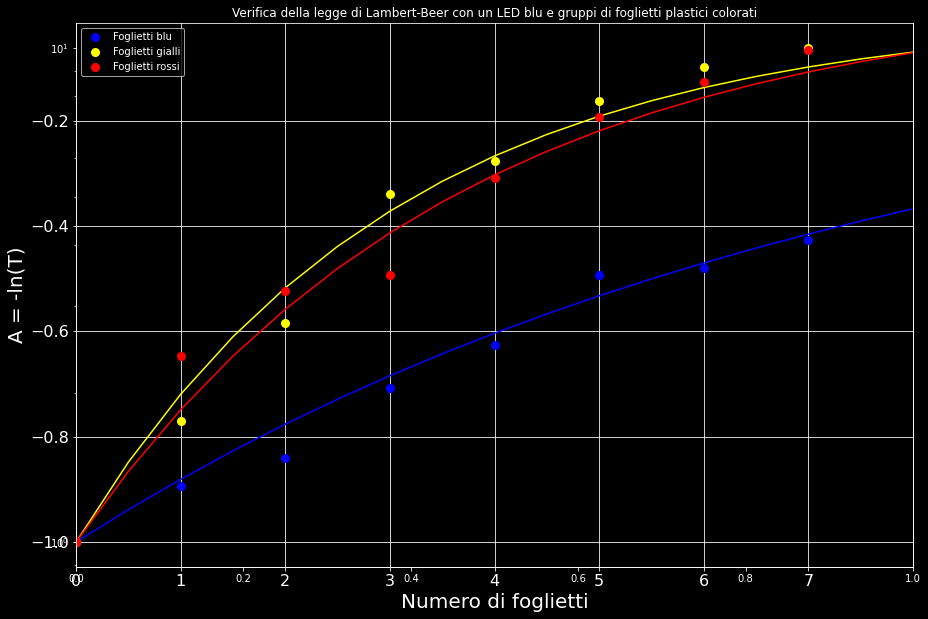

In [ ]:
# Plot di A

plt.figure(figsize=[15,10],facecolor='k')
xmin,xmax=0.,8.
plt.yscale("log")
plt.axes().set_facecolor("k")
plt.title('Verifica della legge di Lambert-Beer con un LED blu e gruppi di foglietti plastici colorati')
plt.xlim(xmin,xmax)
plt.xlabel('Numero di foglietti', fontsize=20)
plt.ylabel('A = -ln(T)', fontsize=20)
plt.xticks(ticks=x_ticks, fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)

plt.plot(sheet_number_blue, -intensity_blue/max(intensity_blue), 'o',markersize=8,color='blue',label='Foglietti blu')
y_blue=function_blue(x,alpha_fit_blue,Ib_fit_blue)
plt.plot(x,-y_blue/max(y_blue),color='blue')

plt.plot(sheet_number_yellow, -intensity_yellow/max(intensity_yellow), 'o',markersize=8,color='yellow',label='Foglietti gialli')
y_yellow=function_yellow(x,alpha_fit_yellow,Ib_fit_yellow)
plt.plot(x,-y_yellow/max(y_yellow),color='yellow')

plt.plot(sheet_number_red, -intensity_red/max(intensity_red), 'o',markersize=8,color='red',label='Foglietti rossi')
y_red=function_red(x,alpha_fit_red,Ib_fit_red)
plt.plot(x,-y_red/max(y_red),color='red')

plt.legend()

### LED verde 

In [ ]:
# Definisci funzione di fit

def function_blue(N,alpha,Ib):
    I = I0_blue*np.exp(-alpha*N)+Ib
    return I

def function_red(N,alpha,Ib):
    I = I0_red*np.exp(-alpha*N)+Ib
    return I

def function_yellow(N,alpha,Ib):
    I = I0_yellow*np.exp(-alpha*N)+Ib
    return I

# Importa i dati

blue = 'https://github.com/nikitodos/UniPV_Physics_Lab_3/raw/main/06_LED_ABSORB/LED_GREEN/LAYERS_BLUE.CSV'
red = 'https://github.com/nikitodos/UniPV_Physics_Lab_3/raw/main/06_LED_ABSORB/LED_GREEN/LAYERS_RED.CSV'
yellow = 'https://github.com/nikitodos/UniPV_Physics_Lab_3/raw/main/06_LED_ABSORB/LED_GREEN/LAYERS_YELLOW.CSV'

blue = pd.read_csv(blue)
red = pd.read_csv(red)
yellow = pd.read_csv(yellow)

# Converti i dati in numpy arrays, usando unità del S.I.

sheet_number_blue=blue['Numero foglietti'].to_numpy()
intensity_blue=blue['Intensità segnale di uscita (mV)'].to_numpy()

sheet_number_red=red['Numero foglietti'].to_numpy()
intensity_red=red['Intensità segnale di uscita (mV)'].to_numpy()

sheet_number_yellow=yellow['Numero foglietti'].to_numpy()
intensity_yellow=yellow['Intensità segnale di uscita (mV)'].to_numpy()

# Definisci variabili di lavoro

I0_blue=intensity_blue[0]
ndata_blue=len(sheet_number_blue)
ni=len(intensity_blue)

I0_red=intensity_red[0]
ndata_red=len(sheet_number_red)
ni_red=len(intensity_red)

I0_yellow=intensity_yellow[0]
ndata_yellow=len(sheet_number_yellow)
ni_yellow=len(intensity_yellow)

print('Inizializzazione dei dati completata.')

Inizializzazione dei dati completata.


 
Dati del fit relativi al LED verde
 
Foglietti blu
Valore di fit del coefficiente di assorbimento:   alpha_fit = ( 4.61e-01  ± 2.5e-01 ) m^{-1}
Valore di fit dell'intensità di fondo:            Ib_fit    = ( 7.1e+00 ± 2.7e+01   ) A
 
Foglietti rossi
Valore di fit del coefficiente di assorbimento:   alpha_fit = ( 4.73e-01  ± 1.6e-01 ) m^{-1}
Valore di fit dell'intensità di fondo:            Ib_fit    = ( 1.74e+00 ± 5.0e+00  ) V
 
Foglietti gialli
Valore di fit del coefficiente di assorbimento:   alpha_fit = ( 3.13e-01  ± 9.5e-02 ) m^{-1}
Valore di fit dell'intensità di fondo:            Ib_fit    = ( 6.53e-01 ± 9.7e+00  ) V
 


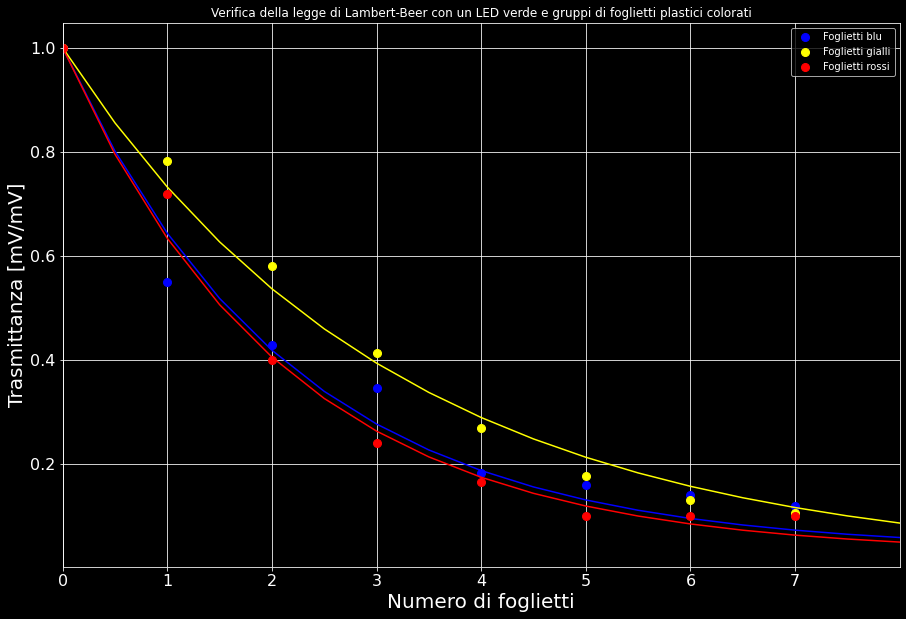

In [ ]:
# Fit dei dati

alpha_min, alpha_max = 0.1, 1
Ib_min, Ib_max = 0, 10
bounds = [ [alpha_min, Ib_min], [alpha_max, Ib_max] ]

popt, pcov=sop.curve_fit(function_blue, sheet_number_blue, intensity_blue, bounds=bounds)
alpha_fit_blue = popt[0]
Ib_fit_blue    = popt[1]
standard_error_blue = np.sqrt(np.diag(pcov))
sigma_blue = np.sqrt(ndata_blue*np.diag(pcov))

alpha_min, alpha_max = 0.4, 0.6
Ib_min, Ib_max = 1.5, 2
bounds = [ [alpha_min, Ib_min], [alpha_max, Ib_max] ]

popt, pcov=sop.curve_fit(function_red, sheet_number_red, intensity_red, bounds=bounds)
alpha_fit_red = popt[0]
Ib_fit_red    = popt[1]
standard_error_red = np.sqrt(np.diag(pcov))
sigma_red = np.sqrt(ndata_red*np.diag(pcov))

alpha_min, alpha_max = 0.1, 1
Ib_min, Ib_max = -10, 10
bounds = [ [alpha_min, Ib_min], [alpha_max, Ib_max] ]

popt, pcov=sop.curve_fit(function_yellow, sheet_number_yellow, intensity_yellow, bounds=bounds)
alpha_fit_yellow = popt[0]
Ib_fit_yellow    = popt[1]
standard_error_yellow = np.sqrt(np.diag(pcov))
sigma_yellow = np.sqrt(ndata_yellow*np.diag(pcov))

print(' ')

print('Dati del fit relativi al LED verde')

print(' ')


print('Foglietti blu')
print('Valore di fit del coefficiente di assorbimento:   alpha_fit = (',np.format_float_scientific(alpha_fit_blue,precision=2), ' ±', np.format_float_scientific(sigma_blue[0], precision=1), ") m^{-1}")
print('Valore di fit dell\'intensità di fondo:            Ib_fit    = (',np.format_float_scientific(Ib_fit_blue,precision=2),   '±', np.format_float_scientific(sigma_blue[1], precision=1), "  ) A")

print(' ')

print('Foglietti rossi') 
print('Valore di fit del coefficiente di assorbimento:   alpha_fit = (',np.format_float_scientific(alpha_fit_red,precision=2), ' ±', np.format_float_scientific(sigma_red[0], precision=1), ") m^{-1}")
print('Valore di fit dell\'intensità di fondo:            Ib_fit    = (',np.format_float_scientific(Ib_fit_red,precision=2),   '±', np.format_float_scientific(sigma_red[1], precision=1), " ) V")

print(' ')

print('Foglietti gialli')
print('Valore di fit del coefficiente di assorbimento:   alpha_fit = (',np.format_float_scientific(alpha_fit_yellow,precision=2), ' ±', np.format_float_scientific(sigma_yellow[0], precision=1), ") m^{-1}")
print('Valore di fit dell\'intensità di fondo:            Ib_fit    = (',np.format_float_scientific(Ib_fit_yellow,precision=2),   '±', np.format_float_scientific(sigma_yellow[1], precision=1), " ) V")

print(' ')

# Plot dati fittati più dati reali

plt.figure(figsize=[15,10])
xmin,xmax=0.,8.
x=np.arange(xmin,xmax+1e-5,0.5)
x_ticks=sheet_number_blue
plt.title('Verifica della legge di Lambert-Beer con un LED verde e gruppi di foglietti plastici colorati')
plt.xlim(xmin,xmax)
plt.xlabel('Numero di foglietti', fontsize=20)
plt.ylabel('Trasmittanza [mV/mV]', fontsize=20)
plt.xticks(ticks=x_ticks, fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)

plt.plot(sheet_number_blue, intensity_blue/max(intensity_blue), 'o',markersize=8,color='blue',label='Foglietti blu')
y_blue=function_blue(x,alpha_fit_blue,Ib_fit_blue)
plt.plot(x,y_blue/max(y_blue),color='blue')

plt.plot(sheet_number_yellow, intensity_yellow/max(intensity_yellow), 'o',markersize=8,color='yellow',label='Foglietti gialli')
y_yellow=function_yellow(x,alpha_fit_yellow,Ib_fit_yellow)
plt.plot(x,y_yellow/max(y_yellow),color='yellow')

plt.plot(sheet_number_red, intensity_red/max(intensity_red), 'o',markersize=8,color='red',label='Foglietti rossi')
y_red=function_red(x,alpha_fit_red,Ib_fit_red)
plt.plot(x,y_red/max(y_red),color='red')

plt.legend()
plt.style.use("dark_background")


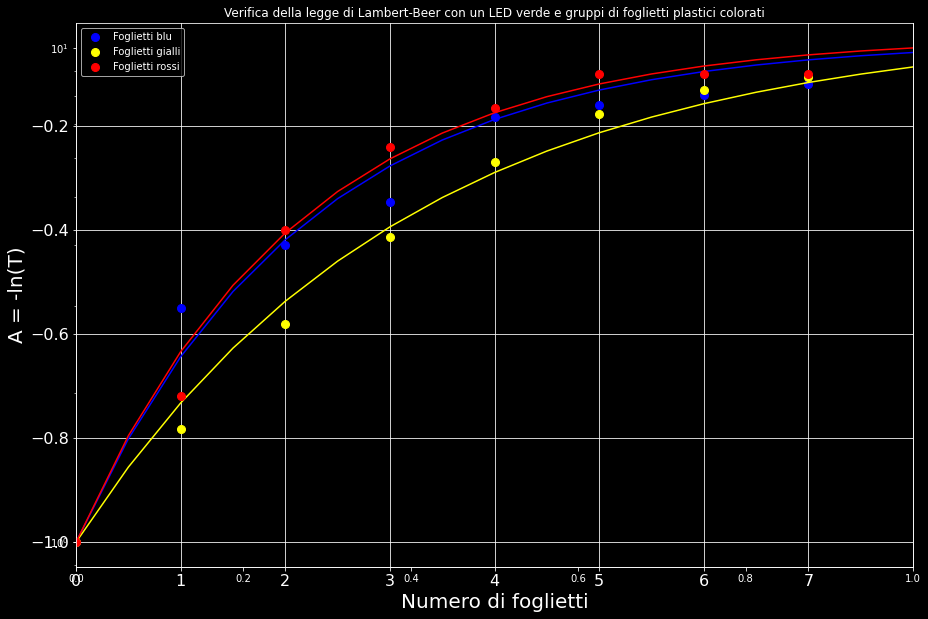

In [ ]:
# Plot di A

plt.figure(figsize=[15,10],facecolor='black')
xmin,xmax=0.,8.
plt.yscale("log")
plt.axes().set_facecolor("black")
x=np.arange(xmin,xmax+1e-5,0.5)
x_ticks=sheet_number_blue
plt.title('Verifica della legge di Lambert-Beer con un LED verde e gruppi di foglietti plastici colorati')
plt.xlim(xmin,xmax)
plt.xlabel('Numero di foglietti', fontsize=20)
plt.ylabel('A = -ln(T)', fontsize=20)
plt.xticks(ticks=x_ticks, fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)

plt.plot(sheet_number_blue, -intensity_blue/max(intensity_blue), 'o',markersize=8,color='blue',label='Foglietti blu')
y_blue=function_blue(x,alpha_fit_blue,Ib_fit_blue)
plt.plot(x,-y_blue/max(y_blue),color='blue')

plt.plot(sheet_number_yellow, -intensity_yellow/max(intensity_yellow), 'o',markersize=8,color='yellow',label='Foglietti gialli')
y_yellow=function_yellow(x,alpha_fit_yellow,Ib_fit_yellow)
plt.plot(x,-y_yellow/max(y_yellow),color='yellow')

plt.plot(sheet_number_red, -intensity_red/max(intensity_red), 'o',markersize=8,color='red',label='Foglietti rossi')
y_red=function_red(x,alpha_fit_red,Ib_fit_red)
plt.plot(x,-y_red/max(y_red),color='red')

plt.legend()

### LED giallo 

In [ ]:
# Definisci funzione di fit

def function_blue(N,alpha,Ib):
    I = I0_blue*np.exp(-alpha*N)+Ib
    return I

def function_red(N,alpha,Ib):
    I = I0_red*np.exp(-alpha*N)+Ib
    return I

def function_yellow(N,alpha,Ib):
    I = I0_yellow*np.exp(-alpha*N)+Ib
    return I

# Importa i dati

blue = 'https://github.com/nikitodos/UniPV_Physics_Lab_3/raw/main/06_LED_ABSORB/LED_YELLOW/LAYERS_BLUE.CSV'
red = 'https://github.com/nikitodos/UniPV_Physics_Lab_3/raw/main/06_LED_ABSORB/LED_YELLOW/LAYERS_RED.CSV'
yellow = 'https://github.com/nikitodos/UniPV_Physics_Lab_3/raw/main/06_LED_ABSORB/LED_YELLOW/LAYERS_YELLOW.CSV'

blue = pd.read_csv(blue)
red = pd.read_csv(red)
yellow = pd.read_csv(yellow)

# Converti i dati in numpy arrays, usando unità del S.I.

sheet_number_blue=blue['Numero foglietti'].to_numpy()
intensity_blue=blue['Intensità segnale di uscita (mV)'].to_numpy()

sheet_number_red=red['Numero foglietti'].to_numpy()
intensity_red=red['Intensità segnale di uscita (mV)'].to_numpy()

sheet_number_yellow=yellow['Numero foglietti'].to_numpy()
intensity_yellow=yellow['Intensità segnale di uscita (mV)'].to_numpy()

# Definisci variabili di lavoro

I0_blue=intensity_blue[0]
ndata_blue=len(sheet_number_blue)
ni=len(intensity_blue)

I0_red=intensity_red[0]
ndata_red=len(sheet_number_red)
ni_red=len(intensity_red)

I0_yellow=intensity_yellow[0]
ndata_yellow=len(sheet_number_yellow)
ni_yellow=len(intensity_yellow)

print('Inizializzazione dei dati completata.')

Inizializzazione dei dati completata.


 
Dati del fit relativi al LED giallo
 
Foglietti blu
Valore di fit del coefficiente di assorbimento:   alpha_fit = ( 3.48e-01  ± 3.2e-02 ) m^{-1}
Valore di fit dell'intensità di fondo:            Ib_fit    = ( 9.73e-01 ± 8.1e+00  ) V
 
Foglietti rossi
Valore di fit del coefficiente di assorbimento:   alpha_fit = ( 6.31e-01  ± 4.2e-02 ) m^{-1}
Valore di fit dell'intensità di fondo:            Ib_fit    = ( 8.34e-01 ± 3.5e+00  ) V
 
Foglietti gialli
Valore di fit del coefficiente di assorbimento:   alpha_fit = ( 3.20e-01  ± 1.2e-01 ) m^{-1}
Valore di fit dell'intensità di fondo:            Ib_fit    = ( 3.89e+00 ± 2.5e+01  ) V
 


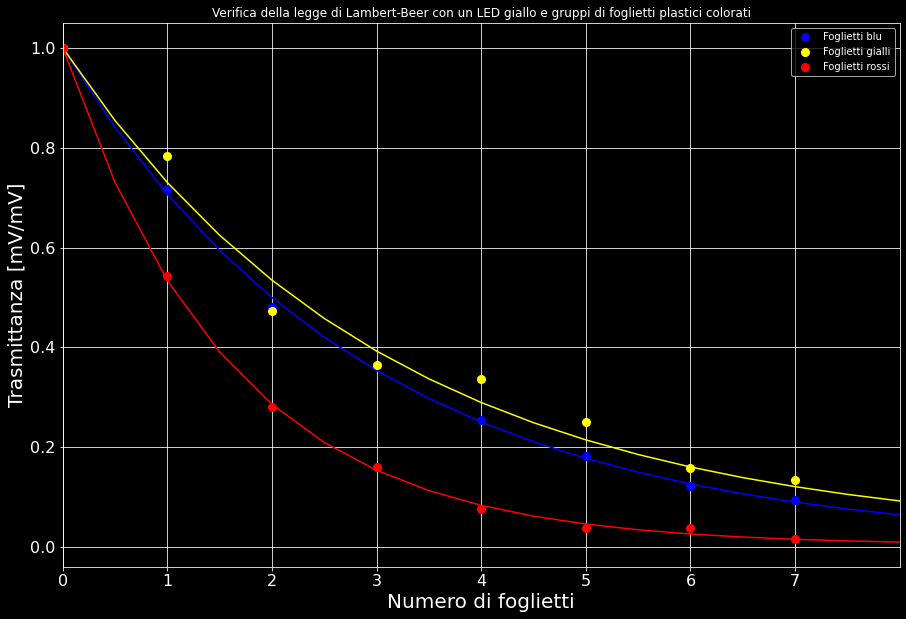

In [ ]:
# Fit dei dati

alpha_min, alpha_max = 0., 5
Ib_min, Ib_max = -100, 100
bounds = [ [alpha_min, Ib_min], [alpha_max, Ib_max] ]

popt, pcov=sop.curve_fit(function_blue, sheet_number_blue, intensity_blue, bounds=bounds)
alpha_fit_blue = popt[0]
Ib_fit_blue    = popt[1]
standard_error_blue = np.sqrt(np.diag(pcov))
sigma_blue = np.sqrt(ndata_blue*np.diag(pcov))

alpha_min, alpha_max = -1e3, 1e3
Ib_min, Ib_max = -20, 20
bounds = [ [alpha_min, Ib_min], [alpha_max, Ib_max] ]

popt, pcov=sop.curve_fit(function_red, sheet_number_red, intensity_red, bounds=bounds)
alpha_fit_red = popt[0]
Ib_fit_red    = popt[1]
standard_error_red = np.sqrt(np.diag(pcov))
sigma_red = np.sqrt(ndata_red*np.diag(pcov))

alpha_min, alpha_max = -100, 100
Ib_min, Ib_max = -1e5, 1e5
bounds = [ [alpha_min, Ib_min], [alpha_max, Ib_max] ]

popt, pcov=sop.curve_fit(function_yellow, sheet_number_yellow, intensity_yellow, bounds=bounds)
alpha_fit_yellow = popt[0]
Ib_fit_yellow    = popt[1]
standard_error_yellow = np.sqrt(np.diag(pcov))
sigma_yellow = np.sqrt(ndata_yellow*np.diag(pcov))

print(' ')

print('Dati del fit relativi al LED giallo')

print(' ')

print('Foglietti blu')
print('Valore di fit del coefficiente di assorbimento:   alpha_fit = (',np.format_float_scientific(alpha_fit_blue,precision=2), ' ±', np.format_float_scientific(sigma_blue[0], precision=1), ") m^{-1}")
print('Valore di fit dell\'intensità di fondo:            Ib_fit    = (',np.format_float_scientific(Ib_fit_blue,precision=2),   '±', np.format_float_scientific(sigma_blue[1], precision=1), " ) V")

print(' ')

print('Foglietti rossi') 
print('Valore di fit del coefficiente di assorbimento:   alpha_fit = (',np.format_float_scientific(alpha_fit_red,precision=2), ' ±', np.format_float_scientific(sigma_red[0], precision=1), ") m^{-1}")
print('Valore di fit dell\'intensità di fondo:            Ib_fit    = (',np.format_float_scientific(Ib_fit_red,precision=2),   '±', np.format_float_scientific(sigma_red[1], precision=1), " ) V")

print(' ')

print('Foglietti gialli')
print('Valore di fit del coefficiente di assorbimento:   alpha_fit = (',np.format_float_scientific(alpha_fit_yellow,precision=2), ' ±', np.format_float_scientific(sigma_yellow[0], precision=1), ") m^{-1}")
print('Valore di fit dell\'intensità di fondo:            Ib_fit    = (',np.format_float_scientific(Ib_fit_yellow,precision=2),   '±', np.format_float_scientific(sigma_yellow[1], precision=1), " ) V")

print(' ')

# Plot dati fittati più dati reali

plt.figure(figsize=[15,10])
xmin,xmax=0.,8.
x=np.arange(xmin,xmax+1e-5,0.5)
x_ticks=sheet_number_blue
plt.title('Verifica della legge di Lambert-Beer con un LED giallo e gruppi di foglietti plastici colorati')
plt.xlim(xmin,xmax)
plt.xlabel('Numero di foglietti', fontsize=20)
plt.ylabel('Trasmittanza [mV/mV]', fontsize=20)
plt.xticks(ticks=x_ticks, fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)

plt.plot(sheet_number_blue, intensity_blue/max(intensity_blue), 'o',markersize=8,color='blue',label='Foglietti blu')
y_blue=function_blue(x,alpha_fit_blue,Ib_fit_blue)
plt.plot(x,y_blue/max(y_blue),color='blue')

plt.plot(sheet_number_yellow, intensity_yellow/max(intensity_yellow), 'o',markersize=8,color='yellow',label='Foglietti gialli')
y_yellow=function_yellow(x,alpha_fit_yellow,Ib_fit_yellow)
plt.plot(x,y_yellow/max(y_yellow),color='yellow')

plt.plot(sheet_number_red, intensity_red/max(intensity_red), 'o',markersize=8,color='red',label='Foglietti rossi')
y_red=function_red(x,alpha_fit_red,Ib_fit_red)
plt.plot(x,y_red/max(y_red),color='red')

plt.legend()
plt.style.use("dark_background")


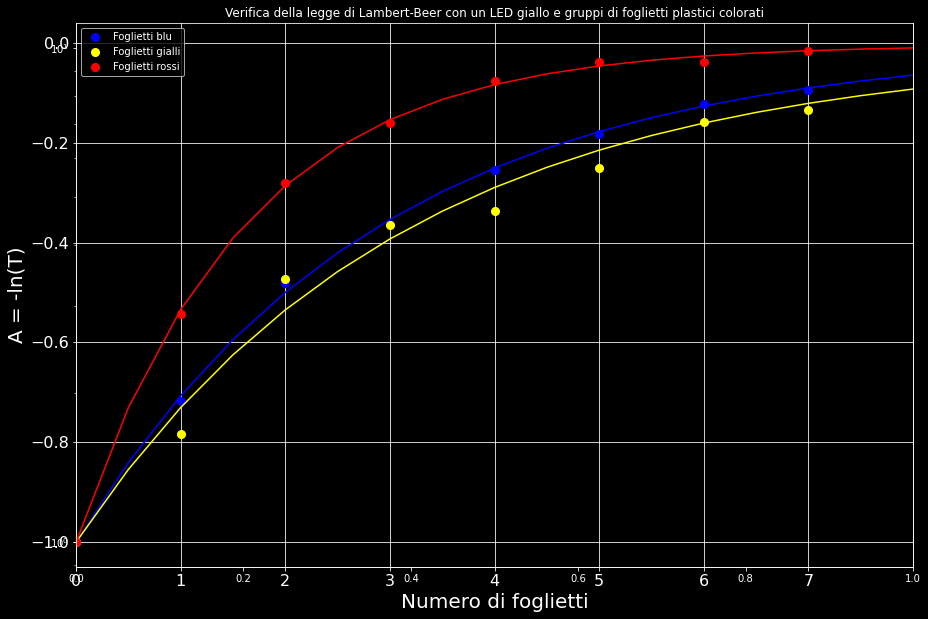

In [ ]:
# Plot di A

plt.figure(figsize=[15,10],facecolor='black')
xmin,xmax=0.,8.
plt.yscale("log")
plt.axes().set_facecolor("black")
x=np.arange(xmin,xmax+1e-5,0.5)
x_ticks=sheet_number_blue
plt.title('Verifica della legge di Lambert-Beer con un LED giallo e gruppi di foglietti plastici colorati')
plt.xlim(xmin,xmax)
plt.xlabel('Numero di foglietti', fontsize=20)
plt.ylabel('A = -ln(T)', fontsize=20)
plt.xticks(ticks=x_ticks, fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)

plt.plot(sheet_number_blue, -intensity_blue/max(intensity_blue), 'o',markersize=8,color='blue',label='Foglietti blu')
y_blue=function_blue(x,alpha_fit_blue,Ib_fit_blue)
plt.plot(x,-y_blue/max(y_blue),color='blue')

plt.plot(sheet_number_yellow, -intensity_yellow/max(intensity_yellow), 'o',markersize=8,color='yellow',label='Foglietti gialli')
y_yellow=function_yellow(x,alpha_fit_yellow,Ib_fit_yellow)
plt.plot(x,-y_yellow/max(y_yellow),color='yellow')

plt.plot(sheet_number_red, -intensity_red/max(intensity_red), 'o',markersize=8,color='red',label='Foglietti rossi')
y_red=function_red(x,alpha_fit_red,Ib_fit_red)
plt.plot(x,-y_red/max(y_red),color='red')

plt.legend()

### LED rosso 

In [ ]:
# Definisci funzione di fit

def function_blue(N,alpha,Ib):
    I = I0_blue*np.exp(-alpha*N)+Ib
    return I

def function_red(N,alpha,Ib):
    I = I0_red*np.exp(-alpha*N)+Ib
    return I

def function_yellow(N,alpha,Ib):
    I = I0_yellow*np.exp(-alpha*N)+Ib
    return I

# Importa i dati

blue = 'https://github.com/nikitodos/UniPV_Physics_Lab_3/raw/main/06_LED_ABSORB/LED_RED/LAYERS_BLUE.CSV'
red = 'https://github.com/nikitodos/UniPV_Physics_Lab_3/raw/main/06_LED_ABSORB/LED_RED/LAYERS_RED.CSV'
yellow = 'https://github.com/nikitodos/UniPV_Physics_Lab_3/raw/main/06_LED_ABSORB/LED_RED/LAYERS_YELLOW.CSV'

blue = pd.read_csv(blue)
red = pd.read_csv(red)
yellow = pd.read_csv(yellow)

# Converti i dati in numpy arrays, usando unità del S.I.

sheet_number_blue=blue['Numero foglietti'].to_numpy()
intensity_blue=blue['Intensità segnale di uscita (mV)'].to_numpy()

sheet_number_red=red['Numero foglietti'].to_numpy()
intensity_red=red['Intensità segnale di uscita (mV)'].to_numpy()

sheet_number_yellow=yellow['Numero foglietti'].to_numpy()
intensity_yellow=yellow['Intensità segnale di uscita (mV)'].to_numpy()

# Definisci variabili di lavoro

I0_blue=intensity_blue[0]
ndata_blue=len(sheet_number_blue)
ni=len(intensity_blue)

I0_red=intensity_red[0]
ndata_red=len(sheet_number_red)
ni_red=len(intensity_red)

I0_yellow=intensity_yellow[0]
ndata_yellow=len(sheet_number_yellow)
ni_yellow=len(intensity_yellow)

print('Inizializzazione dei dati completata.')

Inizializzazione dei dati completata.


 
Dati del fit relativi al LED rosso
 
Foglietti blu
Valore di fit del coefficiente di assorbimento:   alpha_fit = ( 2.73e-01  ± 6.4e-02 ) m^{-1}
Valore di fit dell'intensità di fondo:            Ib_fit    = ( -4.11e+00 ± 4.1e+01 ) A
 
Foglietti rossi
Valore di fit del coefficiente di assorbimento:   alpha_fit = ( 2.56e-01  ± 3.1e-02 ) m^{-1}
Valore di fit dell'intensità di fondo:            Ib_fit    = ( 1.53e+00 ± 2.2e+01 ) A
 
Foglietti gialli
Valore di fit del coefficiente di assorbimento:   alpha_fit = ( 1.82e-01  ± 6.2e-02 ) m^{-1}
Valore di fit dell'intensità di fondo:            Ib_fit    = ( -2.78e+01 ± 6.3e+01 ) A
 


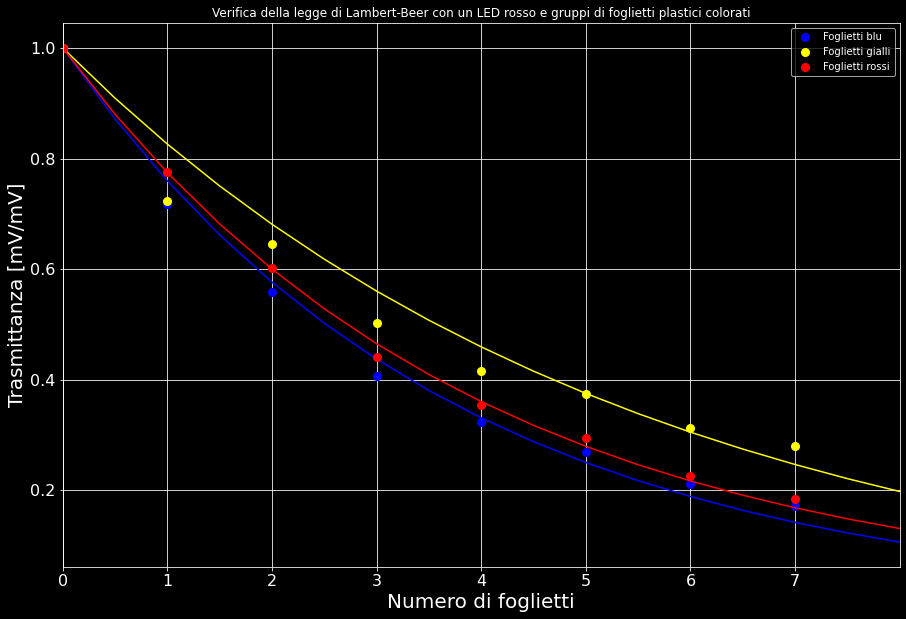

In [ ]:
# Fit dei dati

alpha_min, alpha_max = 0., 5
Ib_min, Ib_max = -100, 100
bounds = [ [alpha_min, Ib_min], [alpha_max, Ib_max] ]

popt, pcov=sop.curve_fit(function_blue, sheet_number_blue, intensity_blue, bounds=bounds)
alpha_fit_blue = popt[0]
Ib_fit_blue    = popt[1]
standard_error_blue = np.sqrt(np.diag(pcov))
sigma_blue = np.sqrt(ndata_blue*np.diag(pcov))

alpha_min, alpha_max = -100, 100
Ib_min, Ib_max = -1e5, 1e5
bounds = [ [alpha_min, Ib_min], [alpha_max, Ib_max] ]

popt, pcov=sop.curve_fit(function_red, sheet_number_red, intensity_red, bounds=bounds)
alpha_fit_red = popt[0]
Ib_fit_red    = popt[1]
standard_error_red = np.sqrt(np.diag(pcov))
sigma_red = np.sqrt(ndata_red*np.diag(pcov))

alpha_min, alpha_max = -100, 100
Ib_min, Ib_max = -1e5, 1e5
bounds = [ [alpha_min, Ib_min], [alpha_max, Ib_max] ]

popt, pcov=sop.curve_fit(function_yellow, sheet_number_yellow, intensity_yellow, bounds=bounds)
alpha_fit_yellow = popt[0]
Ib_fit_yellow    = popt[1]
standard_error_yellow = np.sqrt(np.diag(pcov))
sigma_yellow = np.sqrt(ndata_yellow*np.diag(pcov))

print(' ')

print('Dati del fit relativi al LED rosso')

print(' ')

print('Foglietti blu')
print('Valore di fit del coefficiente di assorbimento:   alpha_fit = (',np.format_float_scientific(alpha_fit_blue,precision=2), ' ±', np.format_float_scientific(sigma_blue[0], precision=1), ") m^{-1}")
print('Valore di fit dell\'intensità di fondo:            Ib_fit    = (',np.format_float_scientific(Ib_fit_blue,precision=2),   '±', np.format_float_scientific(sigma_blue[1], precision=1), ") A")

print(' ')

print('Foglietti rossi') 
print('Valore di fit del coefficiente di assorbimento:   alpha_fit = (',np.format_float_scientific(alpha_fit_red,precision=2), ' ±', np.format_float_scientific(sigma_red[0], precision=1), ") m^{-1}")
print('Valore di fit dell\'intensità di fondo:            Ib_fit    = (',np.format_float_scientific(Ib_fit_red,precision=2),   '±', np.format_float_scientific(sigma_red[1], precision=1), ") A")

print(' ')

print('Foglietti gialli')
print('Valore di fit del coefficiente di assorbimento:   alpha_fit = (',np.format_float_scientific(alpha_fit_yellow,precision=2), ' ±', np.format_float_scientific(sigma_yellow[0], precision=1), ") m^{-1}")
print('Valore di fit dell\'intensità di fondo:            Ib_fit    = (',np.format_float_scientific(Ib_fit_yellow,precision=2),   '±', np.format_float_scientific(sigma_yellow[1], precision=1), ") A")

print(' ')

# Plot dati fittati più dati reali

plt.figure(figsize=[15,10])
xmin,xmax=0.,8.
x=np.arange(xmin,xmax+1e-5,0.5)
x_ticks=sheet_number_blue
plt.title('Verifica della legge di Lambert-Beer con un LED rosso e gruppi di foglietti plastici colorati')
plt.xlim(xmin,xmax)
plt.xlabel('Numero di foglietti', fontsize=20)
plt.ylabel('Trasmittanza [mV/mV]', fontsize=20)
plt.xticks(ticks=x_ticks, fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)

plt.plot(sheet_number_blue, intensity_blue/max(intensity_blue), 'o',markersize=8,color='blue',label='Foglietti blu')
y_blue=function_blue(x,alpha_fit_blue,Ib_fit_blue)
plt.plot(x,y_blue/max(y_blue),color='blue')

plt.plot(sheet_number_yellow, intensity_yellow/max(intensity_yellow), 'o',markersize=8,color='yellow',label='Foglietti gialli')
y_yellow=function_yellow(x,alpha_fit_yellow,Ib_fit_yellow)
plt.plot(x,y_yellow/max(y_yellow),color='yellow')

plt.plot(sheet_number_red, intensity_red/max(intensity_red), 'o',markersize=8,color='red',label='Foglietti rossi')
y_red=function_red(x,alpha_fit_red,Ib_fit_red)
plt.plot(x,y_red/max(y_red),color='red')

plt.legend()
plt.style.use("dark_background")


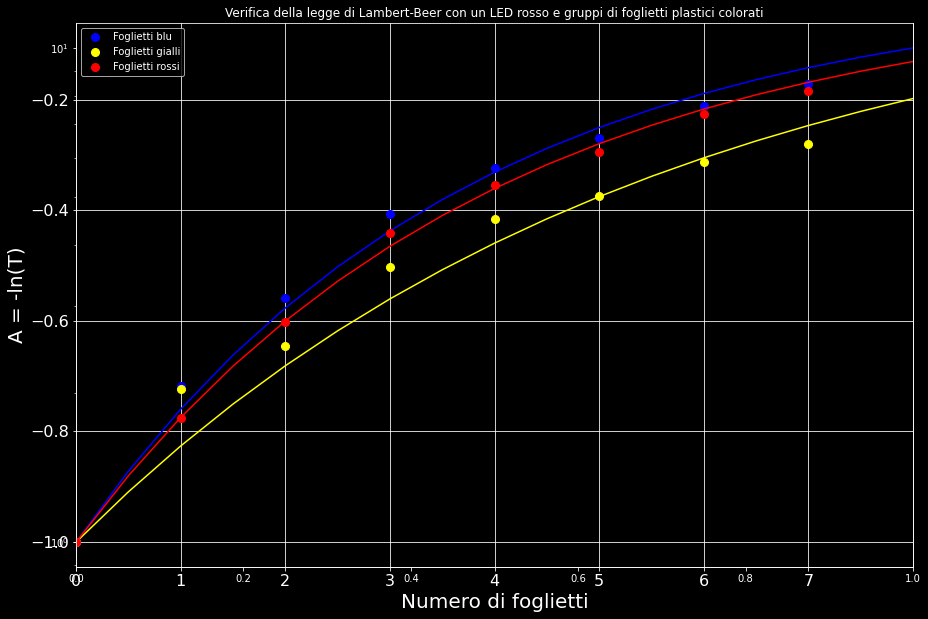

In [ ]:
# Plot di A

plt.figure(figsize=[15,10],facecolor='k')
xmin,xmax=0.,8.
plt.yscale("log")
plt.axes().set_facecolor("k")
x=np.arange(xmin,xmax+1e-5,0.5)
x_ticks=sheet_number_blue
plt.title('Verifica della legge di Lambert-Beer con un LED rosso e gruppi di foglietti plastici colorati')
plt.xlim(xmin,xmax)
plt.xlabel('Numero di foglietti', fontsize=20)
plt.ylabel('A = -ln(T)', fontsize=20)
plt.xticks(ticks=x_ticks, fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)

plt.plot(sheet_number_blue, -intensity_blue/max(intensity_blue), 'o',markersize=8,color='blue',label='Foglietti blu')
y_blue=function_blue(x,alpha_fit_blue,Ib_fit_blue)
plt.plot(x,-y_blue/max(y_blue),color='blue')

plt.plot(sheet_number_yellow, -intensity_yellow/max(intensity_yellow), 'o',markersize=8,color='yellow',label='Foglietti gialli')
y_yellow=function_yellow(x,alpha_fit_yellow,Ib_fit_yellow)
plt.plot(x,-y_yellow/max(y_yellow),color='yellow')

plt.plot(sheet_number_red, -intensity_red/max(intensity_red), 'o',markersize=8,color='red',label='Foglietti rossi')
y_red=function_red(x,alpha_fit_red,Ib_fit_red)
plt.plot(x,-y_red/max(y_red),color='red')

plt.legend()

## Discussione dei risultati e conclusioni

Dall'analisi dei dati sperimentali relativi alle misure effettuate, si nota che il coefficiente di assorbimento varia a seconda del colore dei foglietti; in particolare, quelli rossi assorbono più luce blu di quelli blu, nel caso di LED blu, e la stessa cosa si ripete con foglietti di uguale colore rispetto al LED. Effettivamente questo era proprio ciò che ci si aspettava di vedere: l'assorbimento è maggiore quando la lunghezza d'onda della luce incidente non è uguale alla radiazione di picco del materiale opaco.

Dal plot della grandezza $A$ è evidente che l'andamento esponenziale poc'anzi descritto è soddisfatto entro piccoli spessori. L'incertezza su questa grandezza è da attribuirsi principalmente a problemi di allineamento tra LED e fotodiodo, lieve rifrazione dovuta a non perfetta perpendicolarità delle placche di plexiglass e dei foglietti rispetto all'elettronica e formazione di piccole bolle d'aria in mezzo ai foglietti che, come si è detto in precedenza, sono stati inumiditi con acqua minerale.

Per i risultati raggiunti, si considerano raggiunti con successo tutti gli obiettivi della prova.